Dataset already present.
Images: 1000  |  Masks: 1000

Using device : cuda
GPU          : Tesla T4
Train: 800 samples  |  Val: 200 samples


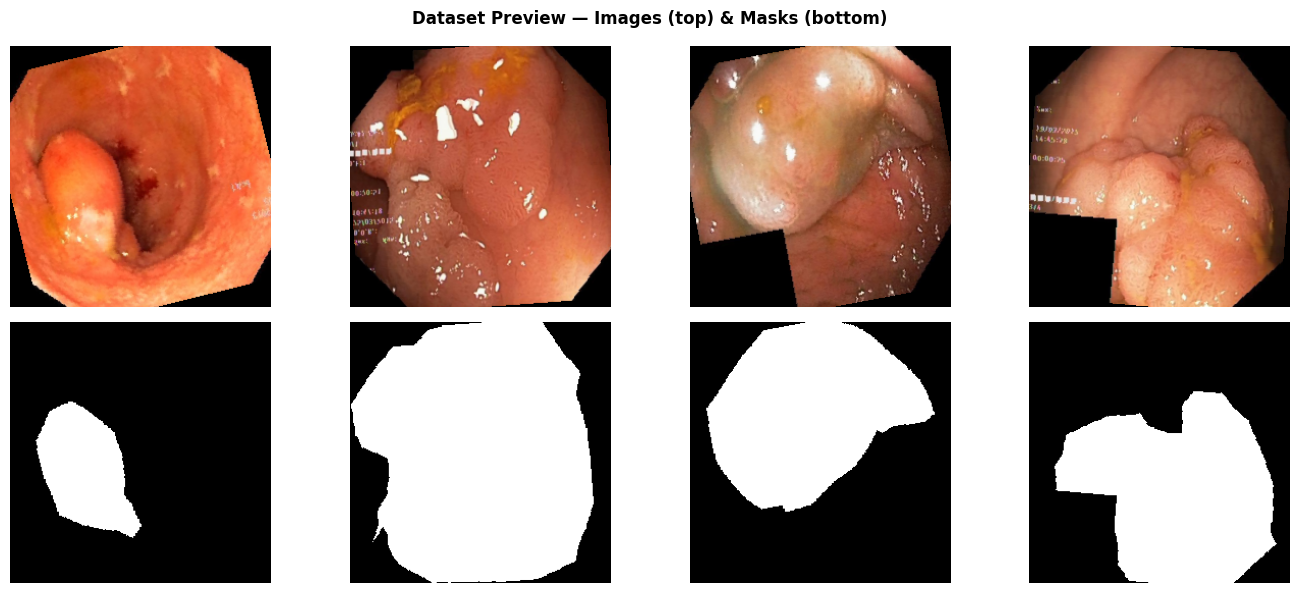


U-Net parameters : 31,037,633
Output shape     : torch.Size([1, 1, 256, 256])

Starting Training


Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Ep 01/30 | Loss T=1.2066 V=1.2457 | Dice T=0.4519 V=0.4618 | IoU  T=0.3235 V=0.3323
  ✓ Best model saved  (Val Dice=0.4618)
Ep 02/30 | Loss T=1.0421 V=1.1649 | Dice T=0.5282 V=0.5022 | IoU  T=0.3941 V=0.3730
  ✓ Best model saved  (Val Dice=0.5022)
Ep 03/30 | Loss T=0.9722 V=0.9486 | Dice T=0.5493 V=0.5590 | IoU  T=0.4177 V=0.4368
  ✓ Best model saved  (Val Dice=0.5590)
Ep 04/30 | Loss T=0.8978 V=0.8699 | Dice T=0.5867 V=0.5983 | IoU  T=0.4595 V=0.4748
  ✓ Best model saved  (Val Dice=0.5983)
Ep 05/30 | Loss T=0.8336 V=0.8194 | Dice T=0.6200 V=0.6113 | IoU  T=0.4944 V=0.4919
  ✓ Best model saved  (Val Dice=0.6113)
Ep 06/30 | Loss T=0.7683 V=0.7311 | Dice T=0.6531 V=0.6767 | IoU  T=0.5326 V=0.5479
  ✓ Best model saved  (Val Dice=0.6767)
Ep 07/30 | Loss T=0.7250 V=0.6970 | Dice T=0.6732 V=0.6902 | IoU  T=0.5528 V=0.5783
  ✓ Best model saved  (Val Dice=0.6902)
Ep 08/30 | Loss T=0.6660 V=0.6425 | Dice T=0.7014 V=0.7229 | IoU  T=0.5863 V=0.6128
  ✓ Best model saved  (Val Dice=0.7229)
Ep 09/30

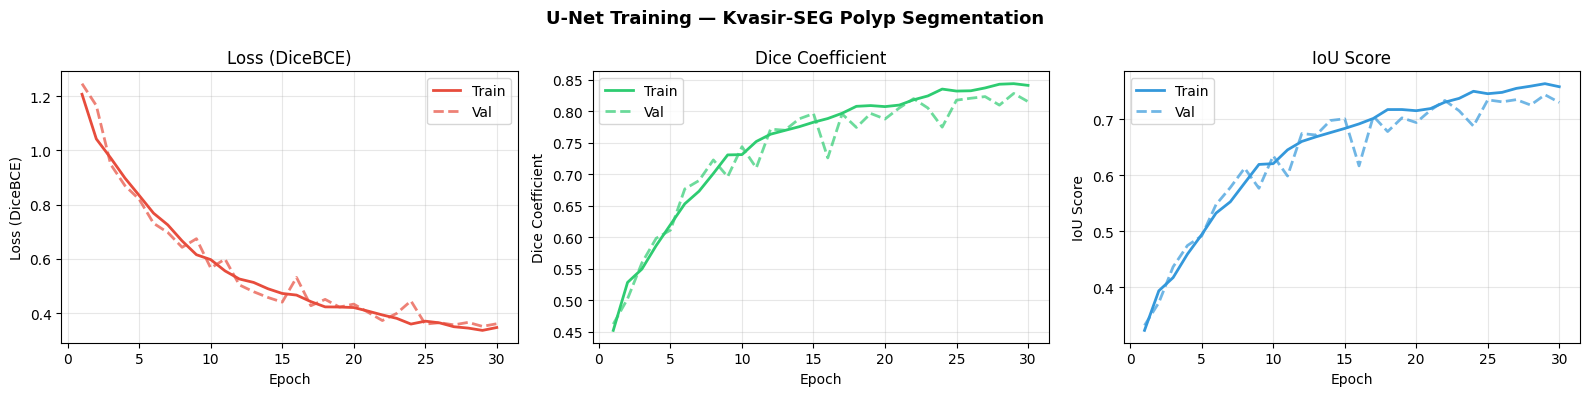

Saved: figures/unet_training_curves.png


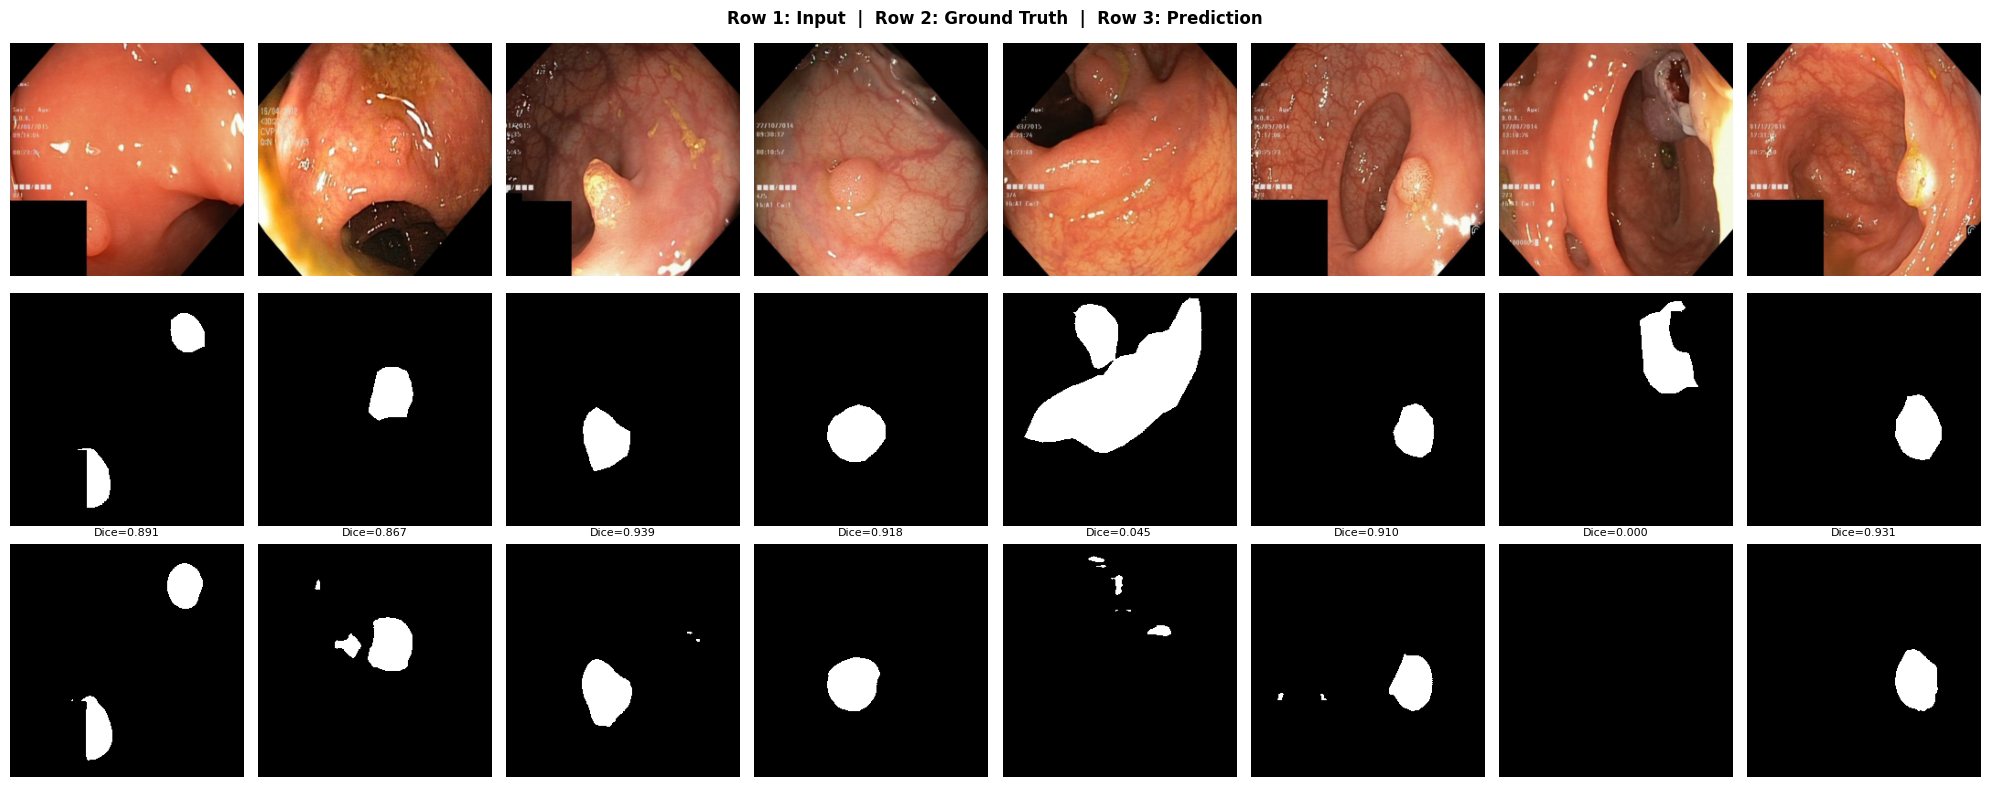

Saved: figures/unet_predictions.png


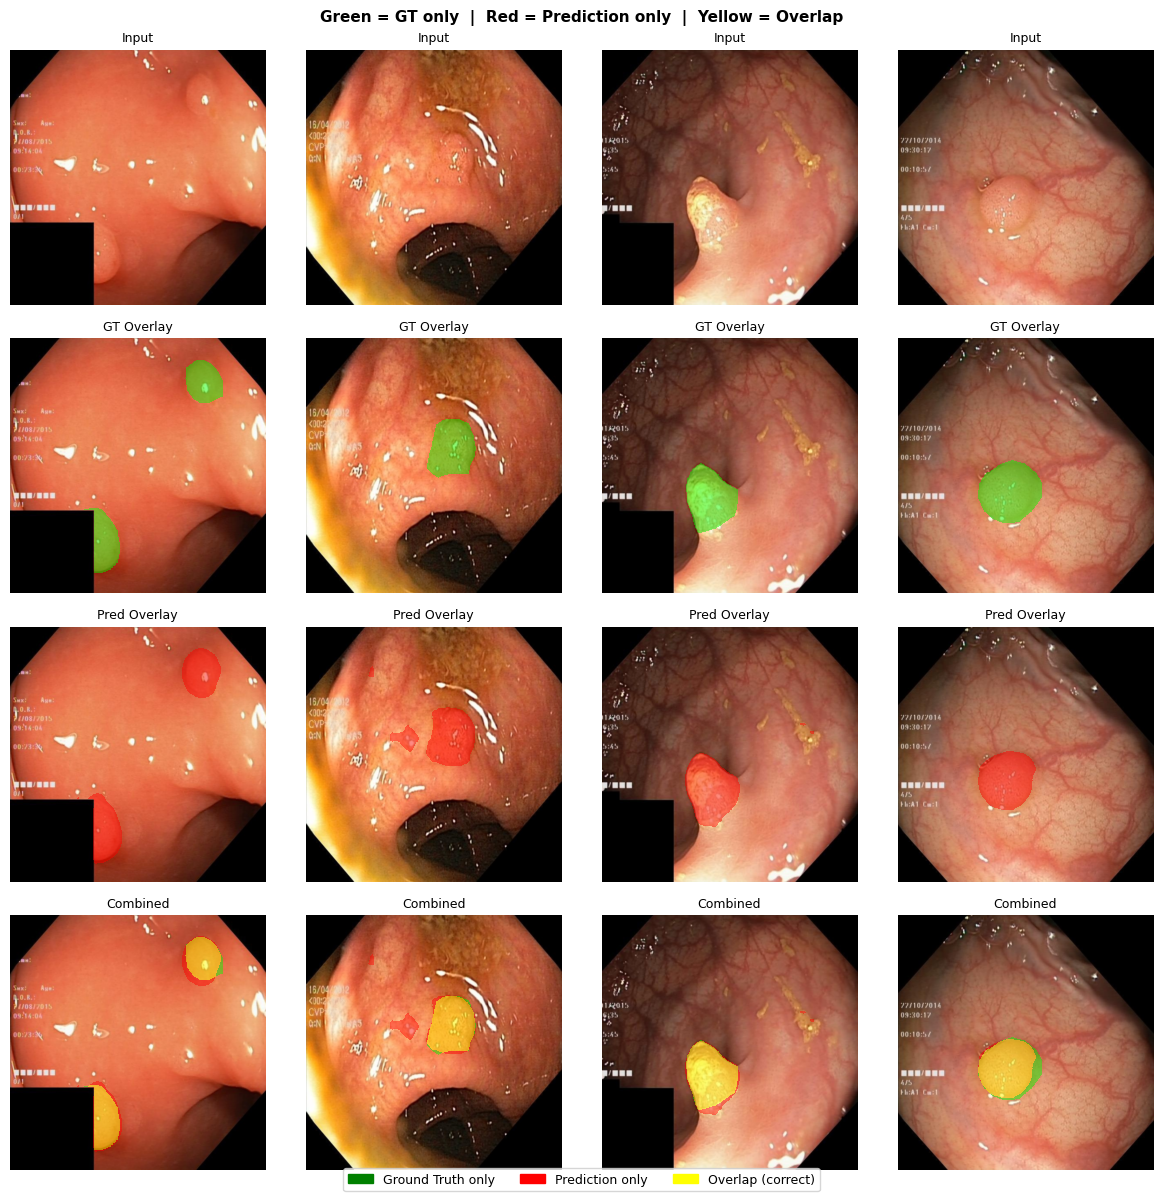

Saved: figures/unet_overlays.png


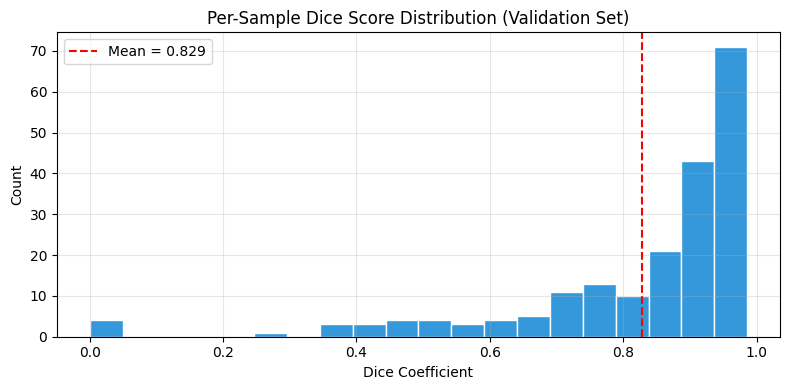

Saved: figures/unet_dice_distribution.png

         FINAL RESULTS SUMMARY
Best Val Dice  : 0.8286
Best Val IoU   : 0.7437
Final Val Dice : 0.8156
Final Val IoU  : 0.7301


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
# ============================================================
# ESE 577 - Lab 4, Part 2: Medical Image Segmentation (U-Net)
# Dataset : Kvasir-SEG (polyp segmentation)
# Paste this entire script into a Google Colab cell and run.
# IMPORTANT: Enable GPU first → Runtime > Change runtime type > T4 GPU
# ============================================================

# ── Step 0: Install / import ──────────────────────────────────────────────────
import os, sys, zipfile, shutil, glob, random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# tqdm works in both Colab and plain Python
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

# ── Step 1: Download Kvasir-SEG via Kaggle ────────────────────────────────────

IMAGE_DIR = 'kvasir-seg/images'
MASK_DIR  = 'kvasir-seg/masks'

if not os.path.isdir(IMAGE_DIR):
    # ── Use the new KGAT_ token format ────────────────────────────────────────
    KAGGLE_TOKEN = "KGAT_fe822194f4d96012810d02d0f68f64a0"
    KAGGLE_USERNAME = "shammykumar"                 # ← your Kaggle username

    os.makedirs('/root/.kaggle', exist_ok=True)
    import json
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_TOKEN}, f)
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    os.system('pip install -q kaggle')
    print("Downloading Kvasir-SEG...")
    ret = os.system('kaggle datasets download -d debeshjha1/kvasirseg')
    assert ret == 0, "Download failed — check username and token"

    zips = [f for f in os.listdir('.') if f.endswith('.zip')]
    with zipfile.ZipFile(zips[0], 'r') as z:
        z.extractall('_raw')
    os.remove(zips[0])

    found_imgs  = sorted(glob.glob('_raw/**/images',  recursive=True))
    found_masks = sorted(glob.glob('_raw/**/masks',   recursive=True))
    os.makedirs('kvasir-seg', exist_ok=True)
    shutil.move(found_imgs[0],  IMAGE_DIR)
    shutil.move(found_masks[0], MASK_DIR)
    shutil.rmtree('_raw', ignore_errors=True)
    print("Dataset ready!")
else:
    print("Dataset already present.")

imgs  = sorted([f for f in os.listdir(IMAGE_DIR)  if f.lower().endswith(('.jpg','.png'))])
masks = sorted([f for f in os.listdir(MASK_DIR)   if f.lower().endswith(('.jpg','.png'))])
print(f"Images: {len(imgs)}  |  Masks: {len(masks)}")
assert len(imgs) == len(masks) > 0, "Mismatch — check IMAGE_DIR / MASK_DIR"

# ── Step 2: Config ────────────────────────────────────────────────────────────
SEED       = 42
IMG_SIZE   = 256
BATCH_SIZE = 8
NUM_EPOCHS = 30
LR         = 1e-4
VAL_SPLIT  = 0.2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device : {device}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU found! Go to Runtime > Change runtime type > T4 GPU")

os.makedirs('figures', exist_ok=True)

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

# ── Step 3: Dataset ───────────────────────────────────────────────────────────
class KvasirDataset(Dataset):
    def __init__(self, img_paths, mask_paths, augment=False):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.augment    = augment
        self.norm = T.Normalize(mean=[0.485, 0.456, 0.406],
                                std =[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.img_paths)

    def _sync_aug(self, img, mask):
        if random.random() > 0.5:
            img, mask = TF.hflip(img), TF.hflip(mask)
        if random.random() > 0.5:
            img, mask = TF.vflip(img), TF.vflip(mask)
        angle = random.uniform(-15, 15)
        return TF.rotate(img, angle), TF.rotate(mask, angle)

    def __getitem__(self, idx):
        img  = Image.open(self.img_paths[idx]).convert('RGB')
        mask = Image.open(self.mask_paths[idx]).convert('L')
        img  = TF.resize(img,  [IMG_SIZE, IMG_SIZE])
        mask = TF.resize(mask, [IMG_SIZE, IMG_SIZE], interpolation=Image.NEAREST)
        if self.augment:
            img, mask = self._sync_aug(img, mask)
        img  = self.norm(TF.to_tensor(img))
        mask = (TF.to_tensor(mask) > 0.5).float()
        return img, mask


def build_loaders():
    img_paths  = sorted(glob.glob(os.path.join(IMAGE_DIR, '*')))
    mask_paths = sorted(glob.glob(os.path.join(MASK_DIR,  '*')))
    idx = list(range(len(img_paths)))
    random.shuffle(idx)
    n_val  = max(1, int(len(idx) * VAL_SPLIT))
    tr_idx, val_idx = idx[n_val:], idx[:n_val]

    train_ds = KvasirDataset([img_paths[i] for i in tr_idx],
                             [mask_paths[i] for i in tr_idx], augment=True)
    val_ds   = KvasirDataset([img_paths[i] for i in val_idx],
                             [mask_paths[i] for i in val_idx], augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)
    print(f"Train: {len(train_ds)} samples  |  Val: {len(val_ds)} samples")
    return train_loader, val_loader

train_loader, val_loader = build_loaders()

# Dataset preview
imgs_b, masks_b = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Dataset Preview — Images (top) & Masks (bottom)',
             fontsize=12, fontweight='bold')
for i in range(4):
    axes[0,i].imshow((imgs_b[i]*std_t+mean_t).clamp(0,1).permute(1,2,0).numpy())
    axes[1,i].imshow(masks_b[i,0].numpy(), cmap='gray')
    axes[0,i].axis('off'); axes[1,i].axis('off')
plt.tight_layout()
plt.savefig('figures/dataset_preview.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Step 4: U-Net Architecture ────────────────────────────────────────────────
class DoubleConv(nn.Module):
    """Two consecutive (Conv → BN → ReLU) blocks."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    """
    U-Net with 4 encoder/decoder levels.
    Encoder : DoubleConv → MaxPool (x4)
    Bottleneck: DoubleConv
    Decoder : ConvTranspose2d + skip connection + DoubleConv (x4)
    Output  : single-channel logits (sigmoid → probability map)
    """
    def __init__(self, in_channels=3, out_channels=1,
                 features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.pool    = nn.MaxPool2d(2, 2)
        self.upconvs = nn.ModuleList()
        self.decoder = nn.ModuleList()

        ch = in_channels
        for f in features:
            self.encoder.append(DoubleConv(ch, f))
            ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.upconvs.append(
                nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2))
            self.decoder.append(DoubleConv(f * 2, f))

        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc in self.encoder:
            x = enc(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x)
        for i, (up, dec) in enumerate(zip(self.upconvs, self.decoder)):
            x = up(x)
            s = skips[-(i + 1)]
            if x.shape != s.shape:
                x = TF.resize(x, s.shape[2:])
            x = dec(torch.cat([s, x], dim=1))
        return self.final(x)


model    = UNet().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nU-Net parameters : {n_params:,}")
with torch.no_grad():
    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    print(f"Output shape     : {model(dummy).shape}")

# ── Step 5: Loss & Metrics ────────────────────────────────────────────────────
class DiceBCELoss(nn.Module):
    """Dice Loss + Binary Cross-Entropy — standard for binary segmentation."""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, logits, targets):
        bce   = self.bce(logits, targets)
        p     = torch.sigmoid(logits)
        inter = (p * targets).sum(dim=(1,2,3))
        union = p.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
        dice  = 1 - (2 * inter + self.smooth) / (union + self.smooth)
        return bce + dice.mean()


def dice_score(logits, targets, smooth=1.0):
    p     = (torch.sigmoid(logits) > 0.5).float()
    inter = (p * targets).sum(dim=(1,2,3))
    union = p.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
    return ((2 * inter + smooth) / (union + smooth)).mean().item()


def iou_score(logits, targets, smooth=1.0):
    p     = (torch.sigmoid(logits) > 0.5).float()
    inter = (p * targets).sum(dim=(1,2,3))
    union = (p + targets - p * targets).sum(dim=(1,2,3))
    return ((inter + smooth) / (union + smooth)).mean().item()


criterion = DiceBCELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5)

# ── Step 6: Training Loop ─────────────────────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = total_dice = total_iou = 0.0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss   = criterion(logits, masks)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
            total_dice += dice_score(logits, masks)
            total_iou  += iou_score(logits, masks)
    n = len(loader)
    return total_loss/n, total_dice/n, total_iou/n


print("\n" + "="*60)
print("Starting Training")
print("="*60)

history   = {k: [] for k in
             ['train_loss','val_loss','train_dice','val_dice','train_iou','val_iou']}
best_dice = 0.0

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc='Epochs'):
    tl, td, ti = run_epoch(model, train_loader, criterion, optimizer)
    vl, vd, vi = run_epoch(model, val_loader,   criterion)
    scheduler.step(vd)
    for k, v in zip(history.keys(), [tl, vl, td, vd, ti, vi]):
        history[k].append(v)
    print(f"Ep {epoch:02d}/{NUM_EPOCHS} | "
          f"Loss T={tl:.4f} V={vl:.4f} | "
          f"Dice T={td:.4f} V={vd:.4f} | "
          f"IoU  T={ti:.4f} V={vi:.4f}")
    if vd > best_dice:
        best_dice = vd
        torch.save(model.state_dict(), 'unet_best.pth')
        print(f"  ✓ Best model saved  (Val Dice={best_dice:.4f})")

print(f"\nTraining complete!  Best Val Dice: {best_dice:.4f}")

# ── Step 7: Training Curves ───────────────────────────────────────────────────
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('U-Net Training — Kvasir-SEG Polyp Segmentation',
             fontsize=13, fontweight='bold')
for ax, (key, label, color) in zip(axes, [
    ('loss', 'Loss (DiceBCE)',   '#e74c3c'),
    ('dice', 'Dice Coefficient', '#2ecc71'),
    ('iou',  'IoU Score',        '#3498db'),
]):
    ax.plot(epochs, history[f'train_{key}'], label='Train',
            color=color, linewidth=2)
    ax.plot(epochs, history[f'val_{key}'],   label='Val',
            color=color, linewidth=2, linestyle='--', alpha=0.7)
    ax.set_xlabel('Epoch'); ax.set_ylabel(label); ax.set_title(label)
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/unet_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/unet_training_curves.png")

# ── Step 8: Prediction Grid ───────────────────────────────────────────────────
model.load_state_dict(torch.load('unet_best.pth', map_location=device))
model.eval()

all_imgs, all_masks, all_preds = [], [], []
with torch.no_grad():
    for imgs, masks in val_loader:
        logits = model(imgs.to(device)).cpu()
        all_imgs.append(imgs)
        all_masks.append(masks)
        all_preds.append((torch.sigmoid(logits) > 0.5).float())
        if sum(x.shape[0] for x in all_imgs) >= 8:
            break

all_imgs  = torch.cat(all_imgs)[:8]
all_masks = torch.cat(all_masks)[:8]
all_preds = torch.cat(all_preds)[:8]

N = 8
fig, axes = plt.subplots(3, N, figsize=(2.5*N, 8))
fig.suptitle('Row 1: Input  |  Row 2: Ground Truth  |  Row 3: Prediction',
             fontsize=12, fontweight='bold')
for i in range(N):
    img_show = (all_imgs[i]*std_t+mean_t).clamp(0,1).permute(1,2,0).numpy()
    with torch.no_grad():
        d = dice_score(model(all_imgs[i:i+1].to(device)),
                       all_masks[i:i+1].to(device))
    axes[0,i].imshow(img_show)
    axes[1,i].imshow(all_masks[i,0].numpy(), cmap='gray')
    axes[2,i].imshow(all_preds[i,0].numpy(), cmap='gray')
    axes[2,i].set_title(f'Dice={d:.3f}', fontsize=8)
    for r in range(3): axes[r,i].axis('off')
plt.tight_layout()
plt.savefig('figures/unet_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/unet_predictions.png")

# ── Step 9: Colour Overlay ────────────────────────────────────────────────────
def overlay(img_np, mask_np, color, alpha=0.45):
    out = img_np.copy()
    for c, val in enumerate(color):
        out[:,:,c] = np.where(mask_np > 0.5,
                               img_np[:,:,c] * (1-alpha) + val * alpha,
                               img_np[:,:,c])
    return out

N2 = min(4, all_imgs.shape[0])
fig, axes = plt.subplots(4, N2, figsize=(3*N2, 12))
fig.suptitle('Green = GT only  |  Red = Prediction only  |  Yellow = Overlap',
             fontsize=11, fontweight='bold')
for i in range(N2):
    img_np  = (all_imgs[i]*std_t+mean_t).clamp(0,1).permute(1,2,0).numpy()
    gt_np   = all_masks[i,0].numpy()
    pred_np = all_preds[i,0].numpy()
    combined = img_np.copy()
    for mask_bool, col in [
        ((gt_np>0.5) & ~(pred_np>0.5), [0,1,0]),   # GT only  → green
        ((pred_np>0.5) & ~(gt_np>0.5), [1,0,0]),   # pred only → red
        ((gt_np>0.5) & (pred_np>0.5),  [1,1,0]),   # overlap   → yellow
    ]:
        combined = overlay(combined, mask_bool.astype(float), col)
    axes[0,i].imshow(img_np)
    axes[1,i].imshow(overlay(img_np, gt_np,   [0,1,0]))
    axes[2,i].imshow(overlay(img_np, pred_np, [1,0,0]))
    axes[3,i].imshow(combined)
    titles = ['Input','GT Overlay','Pred Overlay','Combined']
    for r in range(4):
        axes[r,i].set_title(titles[r], fontsize=9)
        axes[r,i].axis('off')
p1 = mpatches.Patch(color='green',  label='Ground Truth only')
p2 = mpatches.Patch(color='red',    label='Prediction only')
p3 = mpatches.Patch(color='yellow', label='Overlap (correct)')
fig.legend(handles=[p1,p2,p3], loc='lower center', ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout()
plt.savefig('figures/unet_overlays.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/unet_overlays.png")

# ── Step 10: Dice Distribution & Final Summary ────────────────────────────────
per_dice = []
model.eval()
with torch.no_grad():
    for imgs, masks in val_loader:
        logits = model(imgs.to(device))
        for j in range(imgs.size(0)):
            per_dice.append(dice_score(logits[j:j+1], masks[j:j+1].to(device)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_dice, bins=20, color='#3498db', edgecolor='white')
ax.axvline(np.mean(per_dice), color='red', linestyle='--',
           label=f'Mean = {np.mean(per_dice):.3f}')
ax.set_xlabel('Dice Coefficient'); ax.set_ylabel('Count')
ax.set_title('Per-Sample Dice Score Distribution (Validation Set)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/unet_dice_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/unet_dice_distribution.png")

print("\n" + "="*50)
print("         FINAL RESULTS SUMMARY")
print("="*50)
print(f"Best Val Dice  : {max(history['val_dice']):.4f}")
print(f"Best Val IoU   : {max(history['val_iou']):.4f}")
print(f"Final Val Dice : {history['val_dice'][-1]:.4f}")
print(f"Final Val IoU  : {history['val_iou'][-1]:.4f}")
print("="*50)

# ── Step 11: Download all figures ─────────────────────────────────────────────
import shutil as _shutil
_shutil.make_archive('lab4_part2_figures', 'zip', 'figures')
from google.colab import files
files.download('lab4_part2_figures.zip')
print("Downloading lab4_part2_figures.zip ...")